In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Cardiotocographic.csv')

In [3]:
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


### 1.	Data Cleaning and Preparation:
#### Load the dataset into a data frame or equivalent data structure.
#### Handle missing values appropriately (e.g., imputation, deletion).
#### Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).
#### Detect and treat outliers if necessary.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [5]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [20]:
df.fillna(df.median(), inplace=True)

In [21]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(2)

In [23]:
new_df=df.drop_duplicates()

In [24]:
new_df.duplicated().sum()

np.int64(0)

In [25]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [26]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

### 2.	Statistical Summary:
#### Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).
#### Highlight any interesting findings from this summary.


In [27]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,883.000000,883.000000,883.000000,883.000000,883.000000,883.0,883.0,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.0
mean,131.842621,0.004071,0.000603,0.004952,0.001545,0.0,0.0,42.401260,1.271275,3.170071,8.613856,67.795732,0.338671,1.0
std,9.461012,0.003726,0.001337,0.002718,0.002218,0.0,0.0,15.079872,0.538496,6.036208,4.487502,32.607863,0.588830,0.0
min,106.000000,-0.000122,-0.002467,-0.000101,-0.000124,0.0,0.0,15.000000,0.300000,-1.043619,-0.136053,12.000000,-1.006614,1.0
25%,125.000000,0.000000,0.000000,0.003098,0.000000,0.0,0.0,29.000000,0.900000,0.000000,5.600000,40.000000,0.000000,1.0
50%,133.000000,0.003350,0.000000,0.005051,0.000000,0.0,0.0,41.000000,1.200000,0.000000,8.500000,61.000000,0.000000,1.0
75%,138.000000,0.006719,0.000336,0.006927,0.003084,0.0,0.0,56.000000,1.600000,4.000000,11.400000,92.408185,1.000000,1.0
max,160.000000,0.013861,0.006272,0.012072,0.008197,0.0,0.0,79.000000,3.200000,27.000000,20.000000,176.310998,1.023635,1.0


In [28]:
df.median()
df.quantile([0.25, 0.75])

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0.25,125.0,0.000000,0.000000,0.003098,0.000000,0.0,0.0,29.0,0.9,0.0,5.6,40.000000,0.0,1.0
0.75,138.0,0.006719,0.000336,0.006927,0.003084,0.0,0.0,56.0,1.6,4.0,11.4,92.408185,1.0,1.0


### 3.	Data Visualization:
#### Create histograms or boxplots to visualize the distributions of various numerical variables.
#### Use bar charts or pie charts to display the frequency of categories for categorical variables.
#### Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
#### Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.


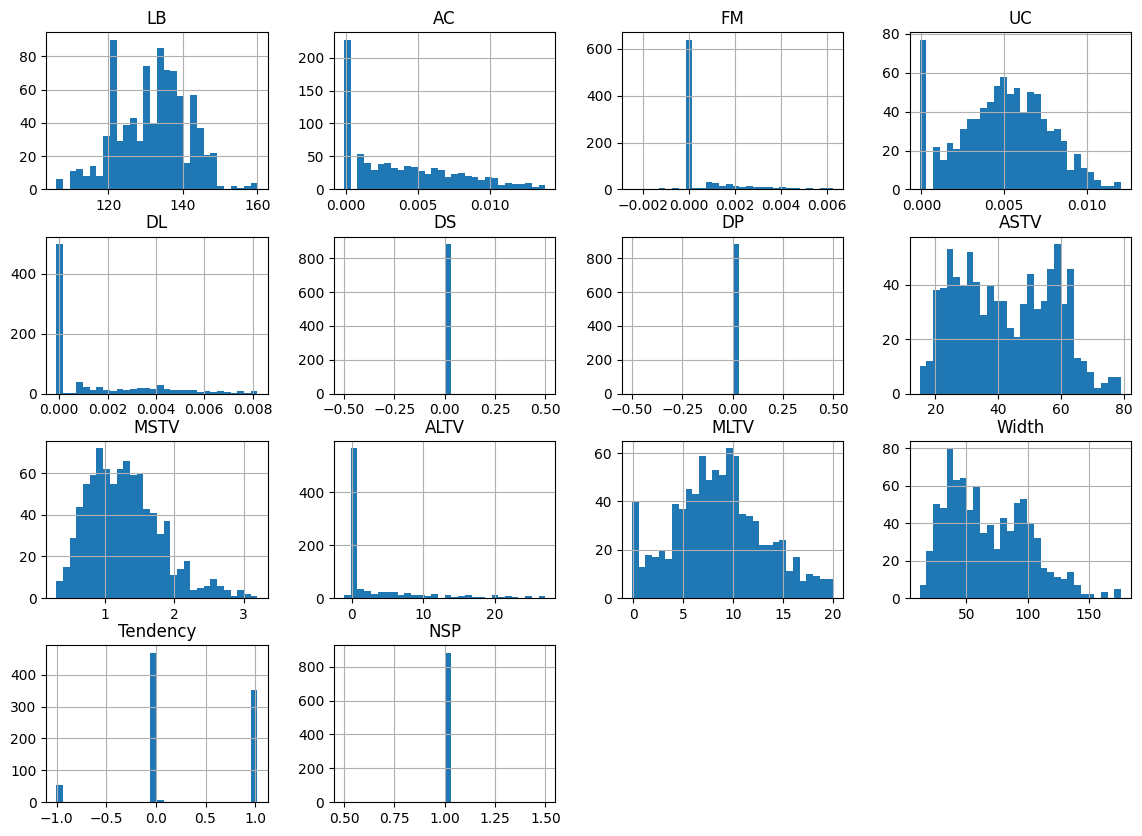

In [29]:
df.hist(figsize=(14,10), bins=30)
plt.show()


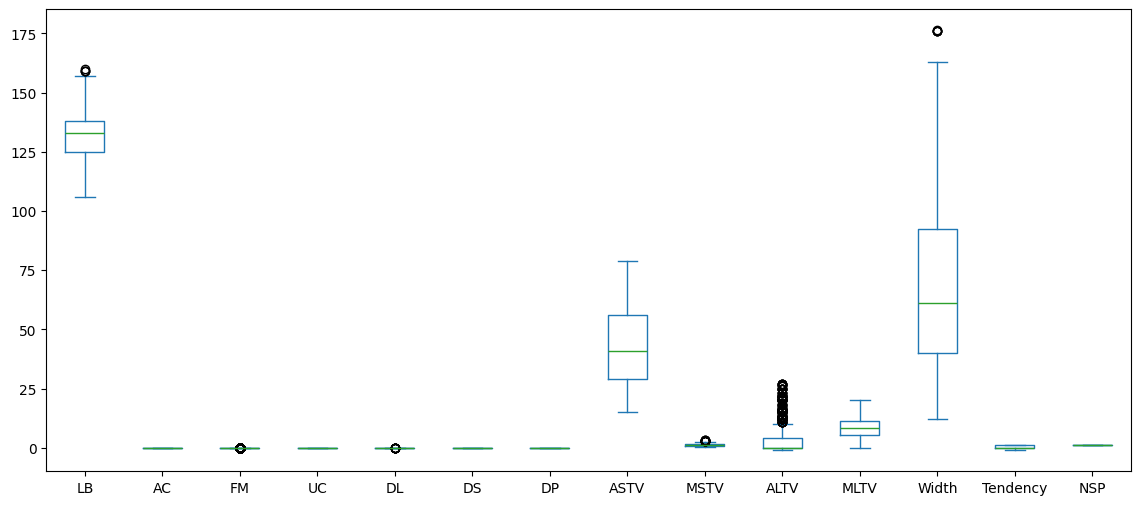

In [30]:
df.plot(kind='box', figsize=(14,6))
plt.show()

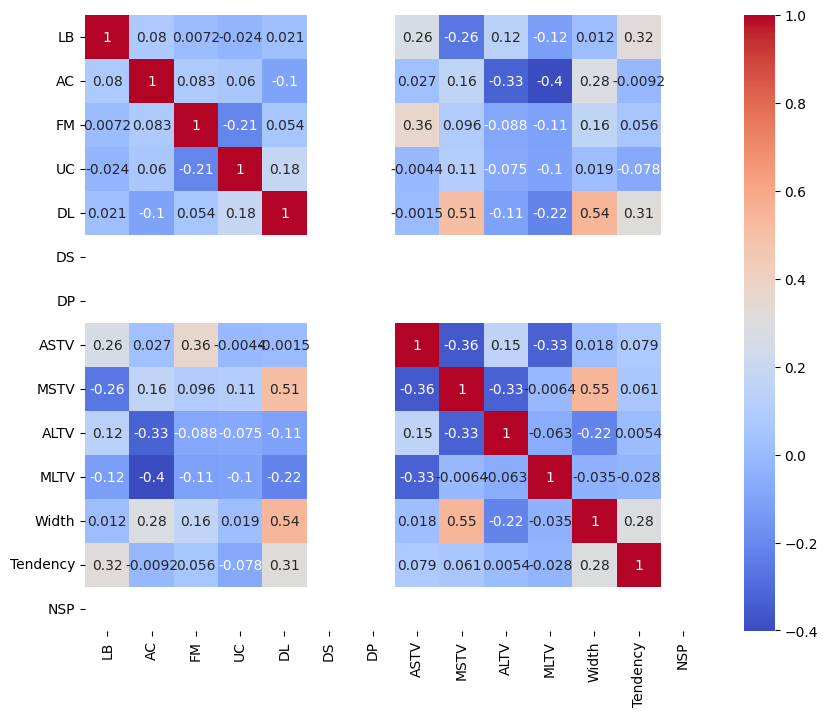

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()


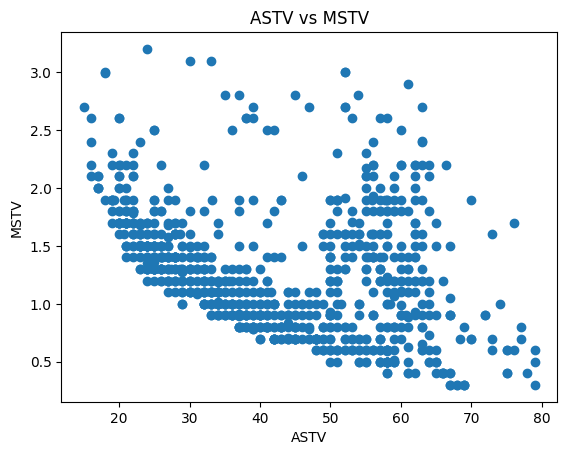

In [32]:
plt.scatter(df['ASTV'], df['MSTV'])
plt.xlabel("ASTV")
plt.ylabel("MSTV")
plt.title("ASTV vs MSTV")
plt.show()

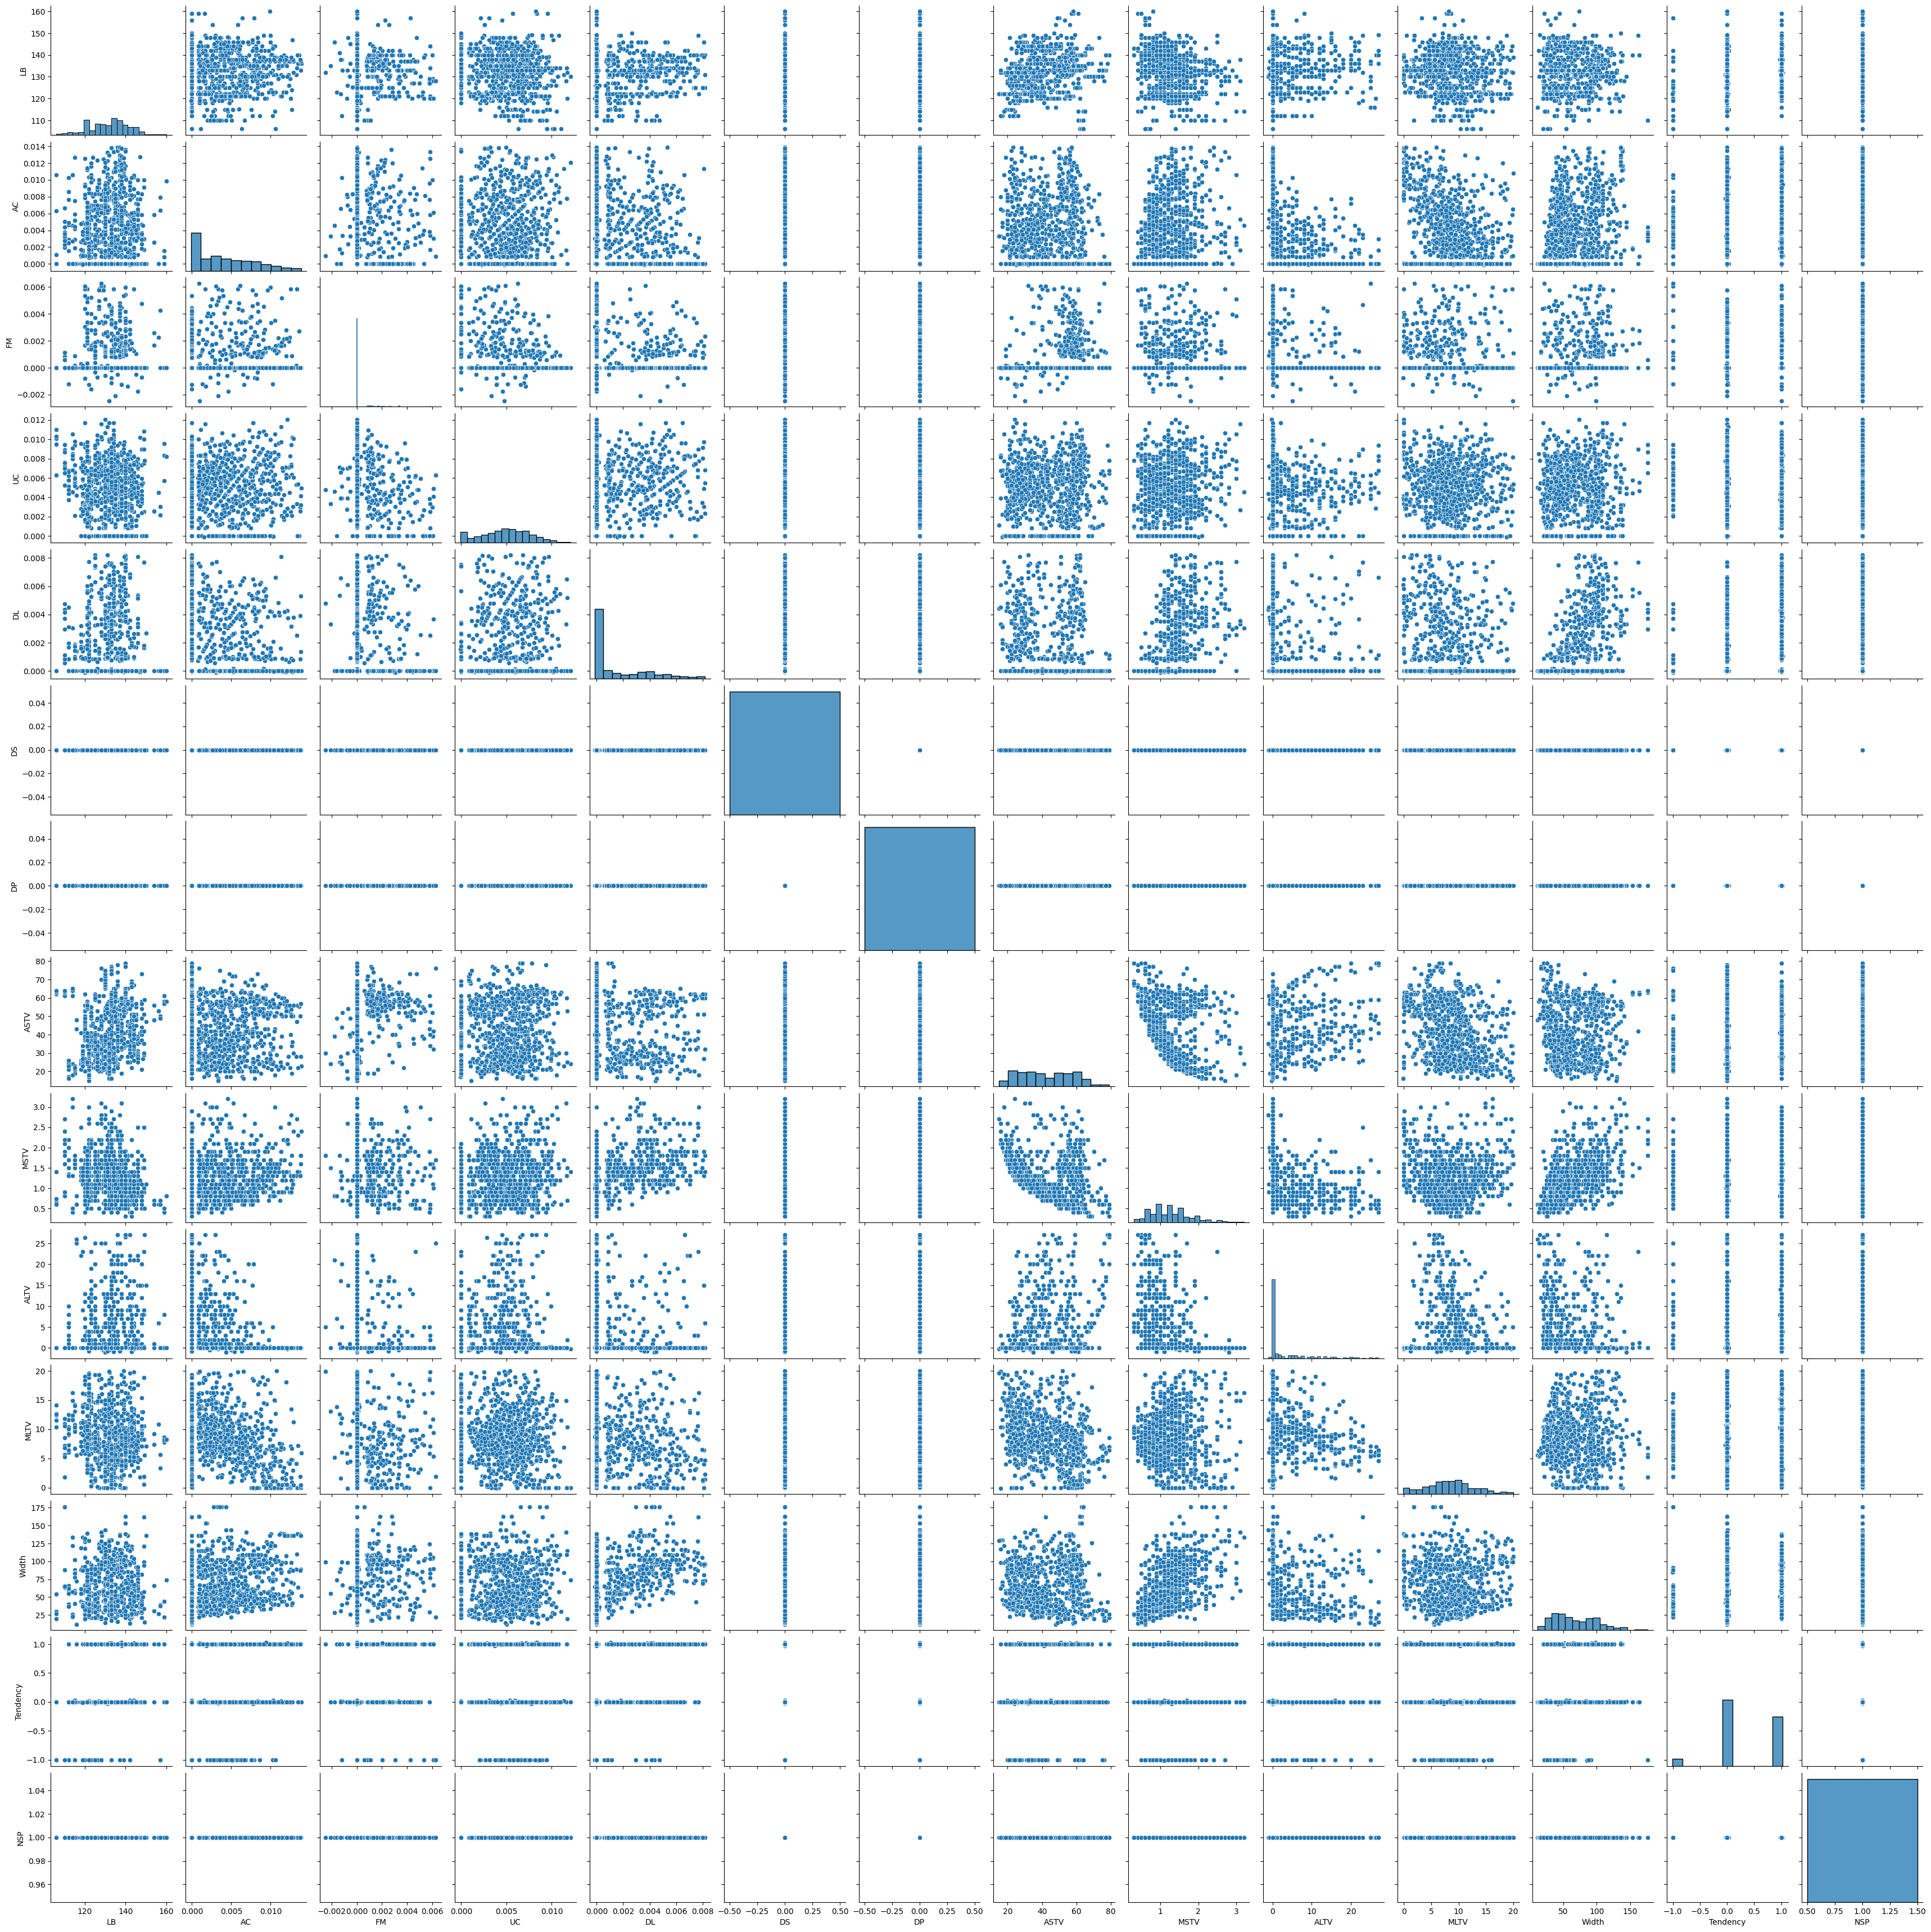

In [33]:
sns.pairplot(df)
plt.show()

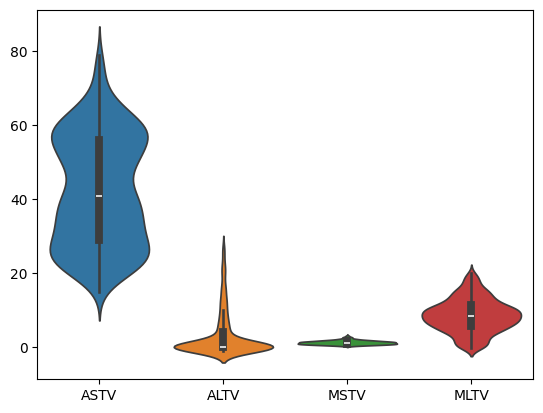

In [34]:
sns.violinplot(data=df[['ASTV','ALTV','MSTV','MLTV']])
plt.show()

# 4.Pattern Recognition and Insights:


#### ASTV MSTV: High abnormal variability reduces normal variability

#### ALTV MLTV: Strong association between long-term variability metrics

#### Decelerations: Uterine Contractions → Indicates fetal stress patterns

# 5. Conclusion:

#### Dataset required minimal cleaning but significant outlier handling

#### Variability metrics (ASTV, MSTV, ALTV, MLTV) are the most influential indicators

#### Deceleration patterns strongly correlate with uterine contractions

#### Distribution skewness highlights rare but critical medical events

### I performed EDA on cardiotocography data by handling missing values, treating outliers, analyzing statistical summaries, and using advanced visualizations like heatmaps and violin plots to identify fetal heart rate variability patterns that can support medical decision-making.